In [1]:
%matplotlib inline
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import QuantLib as ql

In [3]:
today = ql.Date(11, ql.December, 2012)
ql.Settings.instance().evaluationDate = today

<h4>Discounting curver</h4>

In [4]:
eonia = ql.Eonia() #Euro Overnight Index Average


In [5]:
helpers = [
    #TARGET > Trans-European Automated Real-Time Gross Settlement Express Transfer.(European paymeny system)
    ql.DepositRateHelper(ql.QuoteHandle(ql.SimpleQuote(rate/100)),
                         ql.Period(1, ql.Days), fixingDays,
                         ql.TARGET(),ql.Following, False, ql.Actual360())
    for rate, fixingDays in [(0.04, 0), (0.04, 1), (0.04, 2)]
]

In [6]:
helpers += [
    #OIS>Overnight Interest Rate Swap
    ql.DatedOISRateHelper(start_date, end_date,
                         ql.QuoteHandle(ql.SimpleQuote(rate/100)), eonia)
    for rate, start_date, end_date in [( 0.046, ql.Date(16,ql.January,2013), ql.Date(13,ql.February,2013)),
                                       ( 0.016, ql.Date(13,ql.February,2013), ql.Date(13,ql.March,2013)),
                                       (-0.007, ql.Date(13,ql.March,2013), ql.Date(10,ql.April,2013)),
                                       (-0.013, ql.Date(10,ql.April,2013), ql.Date(8,ql.May,2013)),
                                       (-0.014, ql.Date(8,ql.May,2013), ql.Date(12,ql.June,2013))]
    ]

In [7]:
helpers += [
    ql.OISRateHelper(2, ql.Period(*tenor),
                    ql.QuoteHandle(ql.SimpleQuote(rate/100)), eonia)
    for rate, tenor in [(0.002, (15,ql.Months)), (0.008, (18,ql.Months)),
                        (0.021, (21,ql.Months)), (0.036, (2,ql.Years)),
                        (0.127, (3,ql.Years)), (0.274, (4,ql.Years)),
                        (0.456, (5,ql.Years)), (0.647, (6,ql.Years)),
                        (0.827, (7,ql.Years)), (0.996, (8,ql.Years)),
                        (1.147, (9,ql.Years)), (1.280, (10,ql.Years)),
                        (1.404, (11,ql.Years)), (1.516, (12,ql.Years)),
                        (1.764, (15,ql.Years)), (1.939, (20,ql.Years)),
                        (2.003, (25,ql.Years)), (2.038, (30,ql.Years))]
]

In [8]:
jumps = [ql.QuoteHandle(ql.SimpleQuote(math.exp(-J*2.0/360)))
         for J in [0.00102, 0.00086]]
jump_dates = [ql.Date(31, ql.December, 2012), ql.Date(31, ql.December, 2013)]

In [9]:
eonia_curve = ql.PiecewiseLogCubicDiscount(2, ql.TARGET(), helpers,
                                           ql.Actual365Fixed(),
                                           jumps, jump_dates)
eonia_curve.enableExtrapolation()

<h4>6-months Euribor</h4>

As we’ll see, most of the Euribor curves for different tenors have their own quirks.
I’ll start from the 6-months Euribor curve, which is somewhat simpler due to having a number of
quoted rates directly available for bootstrapping. The first instrument used in the paper if the TOM
6-months FRA, which can be instantiated as a 6-months deposit with 3 fixing days; its rate (and
those of all other FRAs) is retrieved from figure 6 in the paper.

In [10]:
helpers = [
    ql.DepositRateHelper(ql.QuoteHandle(ql.SimpleQuote(0.312/100)),
                         ql.Period(6, ql.Months), 3,
                         ql.TARGET(), ql.Following, False, ql.Actual360())
]

Then comes a strip of 6-months FRA up to 2 years maturity:

In [11]:
euribor6m = ql.Euribor6M()

In [12]:
helpers += [
    ql.FraRateHelper(ql.QuoteHandle(ql.SimpleQuote(rate/100)),
                     start, euribor6m)

    for rate, start in [(0.293, 1), (0.272, 2), (0.260, 3),
                        (0.256, 4), (0.252, 5), (0.248, 6),
                        (0.254, 7), (0.261, 8), (0.267, 9),
                        (0.279, 10), (0.291, 11), (0.303, 12),
                        (0.318, 13), (0.335, 14), (0.352, 15),
                        (0.371, 16), (0.389, 17), (0.409, 18)]
]

Finally, we have a series of swap rates with maturities from 3 to 60 years, listed in figure 9. As the paper explains, the curve being bootstrapped will be used only for forecasting the 6-months Euribor fixings paid by the floating leg; all the payments will be discounted by means of the OIS curve, which is wrapped in a Handle and passed as an extra argument to the SwapRateHelper constructor.

In [13]:
discount_curve = ql.RelinkableYieldTermStructureHandle()
discount_curve.linkTo(eonia_curve)

This will give us a decent Euribor curve, that we can display it by sampling 6-months forward rates
at a number of dates.

In [14]:
euribor6m_curve = ql.PiecewiseLogCubicDiscount(2, ql.TARGET(), helpers,
                                              ql.Actual365Fixed())
euribor6m_curve.enableExtrapolation()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (1, 2) + inhomogeneous part.

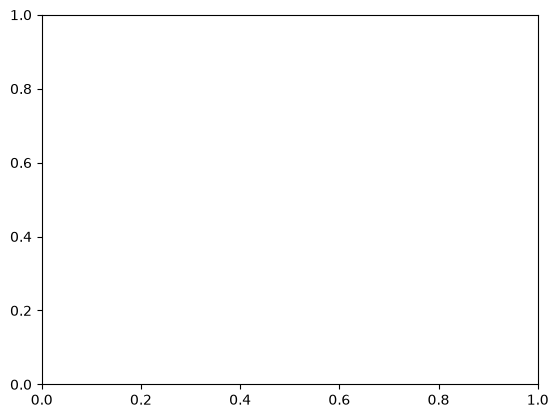

In [15]:
spot = euribor6m_curve.referenceDate()
dates = [spot + ql.Period(i, ql.Months) for i in range(0, 60*12+1)]
rates = [euribor6m_curve.forwardRate(d, euribor6m.maturityDate(d),
                                     ql.Actual360(), ql.Simple).rate()
        for d in dates]
#_ax = utils.plot()
#utils.plot_curve(ax, dates, [(rates,'-')], format_rates=True)
plt.plot(dates, [(rates, '-')])
plt.show()